In [1]:
import pandas as pd
df =pd.read_csv('C:/Users/dell/telco-churn-prediction/data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [3]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [4]:
print(df.isnull().sum())
print(df.dtypes)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      f

In [5]:
df['TotalCharges'].str.strip().eq('').sum()

np.int64(11)

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [8]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [9]:
df[df['TotalCharges'].isnull()]['tenure']

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64

In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [11]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [12]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


C:\Users\dell\AppData\Local\Temp\ipykernel_1684\394053537.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [13]:
df= df.drop('customerID', axis=1)

In [14]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [16]:
df['OnlineSecurity'] = df['OnlineSecurity'].map({'Yes': 1, 'No': 0})
df['OnlineBackup'] = df['OnlineBackup'].map({'Yes': 1, 'No': 0})
df['DeviceProtection'] = df['DeviceProtection'].map({'Yes': 1, 'No': 0})
df['TechSupport'] = df['TechSupport'].map({'Yes': 1, 'No': 0})
df['StreamingTV'] = df['StreamingTV'].map({'Yes': 1, 'No': 0})
df['StreamingMovies'] = df['StreamingMovies'].map({'Yes': 1, 'No': 0})

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,0.0,1.0,0.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,1.0,0.0,1.0,0.0,0.0,0.0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,1.0,1.0,0.0,0.0,0.0,0.0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,1.0,0.0,1.0,1.0,0.0,0.0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,0.0,0.0,0.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,70.70,151.65,1


In [18]:
print(df['OnlineSecurity'].isnull().sum())

1526


In [19]:
df =pd.read_csv('C:/Users/dell/telco-churn-prediction/data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [21]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [22]:
df = df.drop('customerID', axis=1)

In [23]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [24]:
df = pd.get_dummies(df, columns=['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'])

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


In [26]:
df.shape

(7043, 41)

In [27]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [28]:
print(X.shape)
print(y.shape)

(7043, 40)
(7043,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [30]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4930, 40)
(1056, 40)
(1057, 40)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [32]:
X_train[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,4.930000e+03,4.930000e+03,4.930000e+03
mean,1.167423e-16,4.143632e-17,-4.359821e-17
std,1.000101e+00,1.000101e+00,1.000101e+00
min,-1.317619e+00,-1.539324e+00,-1.004128e+00
25%,-9.524160e-01,-9.738588e-01,-8.312369e-01
50%,-1.408545e-01,1.860055e-01,-3.988937e-01
75%,9.547535e-01,8.300071e-01,6.784417e-01
max,1.604003e+00,1.779062e+00,2.784499e+00


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1-score:", f1_score(y_val, y_pred))

Accuracy: 0.8058712121212122
Precision: 0.6459143968871596
Recall: 0.5928571428571429
F1-score: 0.6182495344506518


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model_balanced = LogisticRegression(random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_balanced))
print("Precision:", precision_score(y_val, y_pred_balanced))
print("Recall:", recall_score(y_val, y_pred_balanced))
print("F1-score:", f1_score(y_val, y_pred_balanced))

Accuracy: 0.740530303030303
Precision: 0.5066666666666667
Recall: 0.8142857142857143
F1-score: 0.6246575342465753


In [35]:
from sklearn.ensemble import RandomForestClassifier

model_rf_no_balance = RandomForestClassifier(random_state=42)
model_rf_no_balance.fit(X_train, y_train)

y_pred_rf_nb = model_rf_no_balance.predict(X_val)

print("Sans balancing:")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_nb))
print("Precision:", precision_score(y_val, y_pred_rf_nb))
print("Recall:", recall_score(y_val, y_pred_rf_nb))
print("F1-score:", f1_score(y_val, y_pred_rf_nb))

Sans balancing:
Accuracy: 0.7727272727272727
Precision: 0.5854700854700855
Recall: 0.48928571428571427
F1-score: 0.5330739299610895


In [36]:
from sklearn.ensemble import RandomForestClassifier

model_rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
model_rf_balanced.fit(X_train, y_train)

y_pred_rf_b = model_rf_balanced.predict(X_val)

print("Avec balancing:")
print("Accuracy:", accuracy_score(y_val, y_pred_rf_b))
print("Precision:", precision_score(y_val, y_pred_rf_b))
print("Recall:", recall_score(y_val, y_pred_rf_b))
print("F1-score:", f1_score(y_val, y_pred_rf_b))

Avec balancing:
Accuracy: 0.7755681818181818
Precision: 0.5649546827794562
Recall: 0.6678571428571428
F1-score: 0.6121112929623568


In [37]:
from xgboost import XGBClassifier

model_xgb_no_scale = XGBClassifier(random_state=42)
model_xgb_no_scale.fit(X_train, y_train)

y_pred_xgb_ns = model_xgb_no_scale.predict(X_val)

print("Sans scale_pos_weight:")
print("Accuracy:", accuracy_score(y_val, y_pred_xgb_ns))
print("Precision:", precision_score(y_val, y_pred_xgb_ns))
print("Recall:", recall_score(y_val, y_pred_xgb_ns))
print("F1-score:", f1_score(y_val, y_pred_xgb_ns))

Sans scale_pos_weight:
Accuracy: 0.771780303030303
Precision: 0.5758754863813229
Recall: 0.5285714285714286
F1-score: 0.5512104283054003


In [38]:
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb_scaled = XGBClassifier(random_state=42, scale_pos_weight=scale)
model_xgb_scaled.fit(X_train, y_train)

y_pred_xgb_s = model_xgb_scaled.predict(X_val)

print("Avec scale_pos_weight:")
print("Accuracy:", accuracy_score(y_val, y_pred_xgb_s))
print("Precision:", precision_score(y_val, y_pred_xgb_s))
print("Recall:", recall_score(y_val, y_pred_xgb_s))
print("F1-score:", f1_score(y_val, y_pred_xgb_s))

Avec scale_pos_weight:
Accuracy: 0.7528409090909091
Precision: 0.527536231884058
Recall: 0.65
F1-score: 0.5824


In [39]:
from sklearn.svm import SVC

model_svm_no_balance = SVC(random_state=42)
model_svm_no_balance.fit(X_train, y_train)

y_pred_svm_nb = model_svm_no_balance.predict(X_val)

print("Sans balancing:")
print("Accuracy:", accuracy_score(y_val, y_pred_svm_nb))
print("Precision:", precision_score(y_val, y_pred_svm_nb))
print("Recall:", recall_score(y_val, y_pred_svm_nb))
print("F1-score:", f1_score(y_val, y_pred_svm_nb))

Sans balancing:
Accuracy: 0.8011363636363636
Precision: 0.65625
Recall: 0.525
F1-score: 0.5833333333333334


In [40]:
from sklearn.svm import SVC

model_svm_balanced = SVC(random_state=42, class_weight='balanced')
model_svm_balanced.fit(X_train, y_train)

y_pred_svm_b = model_svm_balanced.predict(X_val)

print("Avec balancing:")
print("Accuracy:", accuracy_score(y_val, y_pred_svm_b))
print("Precision:", precision_score(y_val, y_pred_svm_b))
print("Recall:", recall_score(y_val, y_pred_svm_b))
print("F1-score:", f1_score(y_val, y_pred_svm_b))

Avec balancing:
Accuracy: 0.7395833333333334
Precision: 0.5056179775280899
Recall: 0.8035714285714286
F1-score: 0.6206896551724138


In [41]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd

X_cv=pd.concat([X_train, X_val])
y_cv=pd.concat([y_train, y_val])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


model_log = LogisticRegression(random_state=42, class_weight='balanced')
scores_log = cross_val_score(model_log, X_cv, y_cv, cv=skf, scoring='f1')

print("Logistic Regression - F1 par fold:", scores_log)
print("Logistic Regression - F1 moyen:", scores_log.mean())


model_svm = SVC(random_state=42, class_weight='balanced')
scores_svm = cross_val_score(model_svm, X_cv, y_cv, cv=skf, scoring='f1')

print("SVM - F1 par fold:", scores_svm)
print("SVM - F1 moyen:", scores_svm.mean())


Logistic Regression - F1 par fold: [0.63625154 0.63312883 0.62647754 0.62944162 0.61672909]
Logistic Regression - F1 moyen: 0.6284057260077397
SVM - F1 par fold: [0.62407862 0.62820513 0.61887694 0.63211125 0.605     ]
SVM - F1 moyen: 0.6216543890643235


In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  
}

model_log_tuning = LogisticRegression(random_state=42, class_weight='balanced')

grid_search = GridSearchCV(model_log_tuning, param_grid, cv=skf, scoring='f1', n_jobs=-1)
grid_search.fit(X_cv, y_cv)

print("Meilleurs paramètres:", grid_search.best_params_)
print("Meilleur F1-score:", grid_search.best_score_)

Meilleurs paramètres: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Meilleur F1-score: 0.6286849454403927


C:\Users\dell\telco-churn-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Background dataset has 4930 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4930 when initializing the masker.


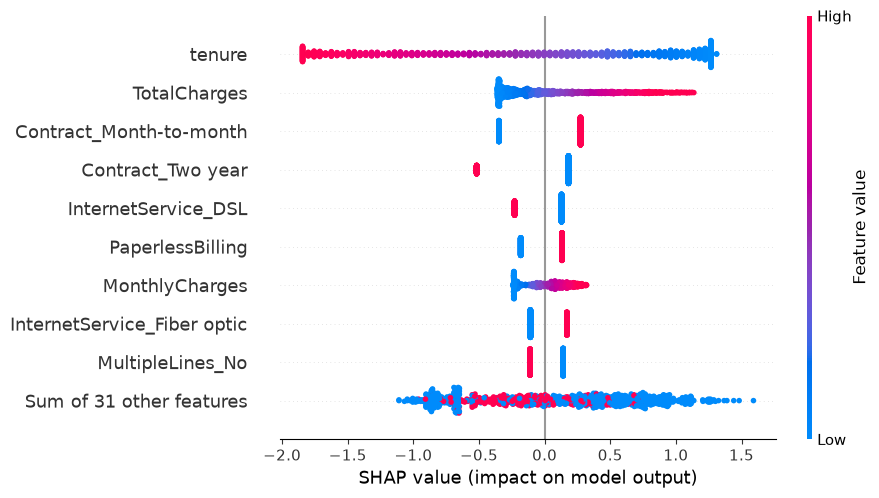

In [44]:

import shap

X_val_numeric = X_val.astype(float)
best_model = grid_search.best_estimator_
explainer = shap.LinearExplainer(best_model, X_train.astype(float))
shap_values = explainer(X_val_numeric)
shap.plots.beeswarm(shap_values)

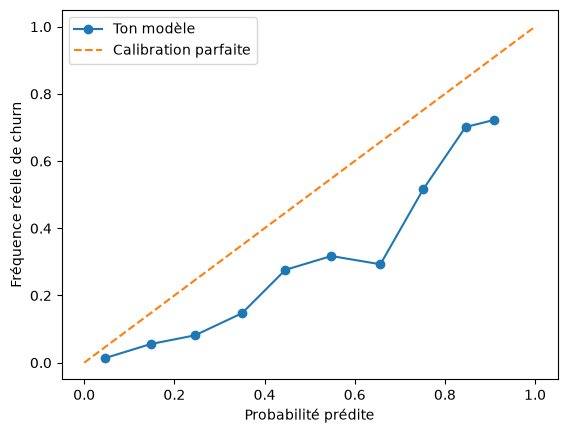

In [45]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_val)[:, 1]

prob_true, prob_pred = calibration_curve(y_val, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Ton modèle')
plt.plot([0, 1], [0, 1], linestyle='--', label='Calibration parfaite')
plt.xlabel('Probabilité prédite')
plt.ylabel('Fréquence réelle de churn')
plt.legend()
plt.show()

In [46]:
from sklearn.metrics import confusion_matrix

y_pred = best_model.predict(X_val)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

cost_fn = 500
cost_fp = 50

total_cost = (fn * cost_fn) + (fp * cost_fp)
print(f"Faux négatifs: {fn}, Faux positifs: {fp}")
print(f"Coût total: {total_cost}€")

Faux négatifs: 52, Faux positifs: 222
Coût total: 37100€


Meilleur seuil: 0.25000000000000006
Coût minimal: 26400€


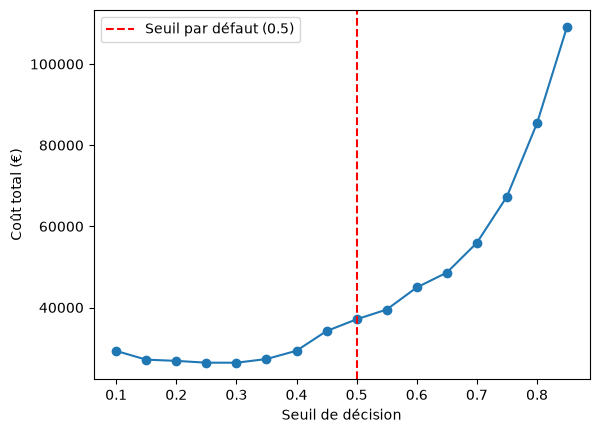

In [47]:
import numpy as np

y_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
costs = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()
    cost = (fn * cost_fn) + (fp * cost_fp)
    costs.append(cost)

best_threshold = thresholds[np.argmin(costs)]
print(f"Meilleur seuil: {best_threshold}")
print(f"Coût minimal: {min(costs)}€")

plt.plot(thresholds, costs, marker='o')
plt.xlabel('Seuil de décision')
plt.ylabel('Coût total (€)')
plt.axvline(x=0.5, color='red', linestyle='--', label='Seuil par défaut (0.5)')
plt.legend()
plt.show()

In [48]:
X_test_numeric = X_test.astype(float)

y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= 0.25).astype(int)

print("=== Résultats finaux sur X_test ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1-score:", f1_score(y_test, y_pred_test))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
cost_test = (fn * cost_fn) + (fp * cost_fp)
print(f"Faux négatifs: {fn}, Faux positifs: {fp}")
print(f"Coût total sur test: {cost_test}€")

=== Résultats finaux sur X_test ===
Accuracy: 0.6215704824976348
Precision: 0.4077519379844961
Recall: 0.9359430604982206
F1-score: 0.5680345572354212
Faux négatifs: 18, Faux positifs: 382
Coût total sur test: 28100€
